# Retail Business Performance & Profitability Analysis

Analyzing transactional retail data to uncover profit-draining categories, examine fulfillment-speed vs profitability, and identify seasonal patterns.

## 1. Import Libraries & Load Data

In [14]:
import os
print(os.getcwd())

C:\Users\Rimcy\Downloads\files


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style('whitegrid')

df = pd.read_csv('superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


## 2. Data Cleaning
Check for missing/null values and fix them.

In [4]:
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing Product Base Margin with category-level median
df['Product Base Margin'] = df.groupby('Product Category')['Product Base Margin'].transform(
    lambda x: x.fillna(x.median())
)

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Remove invalid rows (non-positive sales)
df = df[df['Sales'] > 0]
print("Cleaned shape:", df.shape)

Product Base Margin    63
dtype: int64
Cleaned shape: (8399, 21)


## 3. Feature Engineering

In [5]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Order Month'].apply(get_season)
df.to_csv('superstore_cleaned.csv', index=False)
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date,Order Year,Order Month,Days to Ship,Profit Margin %,Season
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20,2010,10,7,-81.536285,Fall
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02,2012,10,1,4.522465,Fall
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03,2012,10,2,19.098827,Fall
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Telephones and Communication,R380,Small Box,0.58,2011-07-12,2011,7,2,24.144746,Summer
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30,2010,8,2,7.847414,Summer


## 4. SQL Analysis (using SQLite in-memory )

In [6]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

profit_by_category = pd.read_sql_query('''
SELECT [Product Category] AS Category,
       ROUND(SUM(Sales),2) AS Total_Sales,
       ROUND(SUM(Profit),2) AS Total_Profit,
       ROUND(SUM(Profit)*100.0/SUM(Sales),2) AS Profit_Margin_Pct
FROM sales
GROUP BY [Product Category]
ORDER BY Profit_Margin_Pct DESC;
''', conn)
profit_by_category

,Category,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Technology,5984248.18,886313.52,14.81
1,Office Supplies,3752762.10,518021.43,13.80
2,Furniture,5178590.54,117433.03,2.27


In [7]:
profit_by_subcategory = pd.read_sql_query('''
SELECT [Product Category] AS Category,
       [Product Sub-Category] AS Sub_Category,
       ROUND(SUM(Sales),2) AS Total_Sales,
       ROUND(SUM(Profit),2) AS Total_Profit,
       ROUND(SUM(Profit)*100.0/SUM(Sales),2) AS Profit_Margin_Pct
FROM sales
GROUP BY [Product Category], [Product Sub-Category]
ORDER BY Profit_Margin_Pct ASC
LIMIT 10;
''', conn)
profit_by_subcategory

,Category,Sub_Category,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Office Supplies,"Scissors, Rulers and Trimmers",80996.31,-7799.25,-9.63
1,Furniture,Tables,1896008.14,-99062.50,-5.22
2,Furniture,Bookcases,822652.04,-33582.13,-4.08
3,Office Supplies,Rubber Bands,15006.63,-102.67,-0.68
4,Office Supplies,Storage & Organization,1070182.60,6664.15,0.62
5,Office Supplies,Pens & Art Supplies,167107.22,7564.78,4.53
6,Furniture,Chairs & Chairmats,1761836.55,149649.73,8.49
7,Office Supplies,Paper,446452.86,45263.20,10.14
8,Technology,Computer Peripherals,795875.94,94287.48,11.85
9,Office Supplies,Appliances,736991.54,97158.06,13.18


In [8]:
profit_by_region = pd.read_sql_query('''
SELECT Region,
       ROUND(SUM(Sales),2) AS Total_Sales,
       ROUND(SUM(Profit),2) AS Total_Profit,
       ROUND(SUM(Profit)*100.0/SUM(Sales),2) AS Profit_Margin_Pct
FROM sales
GROUP BY Region
ORDER BY Profit_Margin_Pct DESC;
''', conn)
profit_by_region

,Region,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Northwest Territories,800847.33,100653.08,12.57
1,Atlantic,2014248.20,238960.66,11.86
2,Prarie,2837304.60,321160.12,11.32
3,Ontario,3063212.48,346868.54,11.32
4,Quebec,1510195.08,140426.65,9.30
5,West,3597549.28,297008.61,8.26
6,Yukon,975867.37,73849.21,7.57
7,Nunavut,116376.48,2841.11,2.44


## 5. Correlation: Fulfillment Speed (Days to Ship) vs Profitability
Using 'Days to Ship' as a proxy for inventory/fulfillment efficiency.

In [9]:
turnover = df.groupby('Product Sub-Category').agg(
    Avg_Days_To_Ship=('Days to Ship','mean'),
    Avg_Profit_Margin=('Profit Margin %','mean'),
    Total_Sales=('Sales','sum')
).reset_index()

corr = turnover['Avg_Days_To_Ship'].corr(turnover['Avg_Profit_Margin'])
print(f"Correlation (sub-category level): {corr:.3f}")

corr_row = df['Days to Ship'].corr(df['Profit Margin %'])
print(f"Correlation (order level): {corr_row:.3f}")

turnover.sort_values('Avg_Days_To_Ship', ascending=False)

Correlation (sub-category level): 0.286
Correlation (order level): 0.014


,Product Sub-Category,Avg_Days_To_Ship,Avg_Profit_Margin,Total_Sales
6,Envelopes,2.268293,10.665538,174085.800
5,Copiers and Fax,2.195402,-8.917013,1130361.300
16,Telephones and Communication,2.172140,-9.426927,1889313.802
2,Bookcases,2.137566,-17.579566,822652.040
11,Pens & Art Supplies,2.126382,-9.068947,167107.220
12,Rubber Bands,2.072626,-10.467859,15006.630
0,Appliances,2.059908,-45.454531,736991.540
15,Tables,2.044321,-17.998098,1896008.142
9,Office Machines,2.011869,-4.781323,2168697.140
14,Storage & Organization,2.007326,-24.129095,1070182.600


## 6. Visualizations

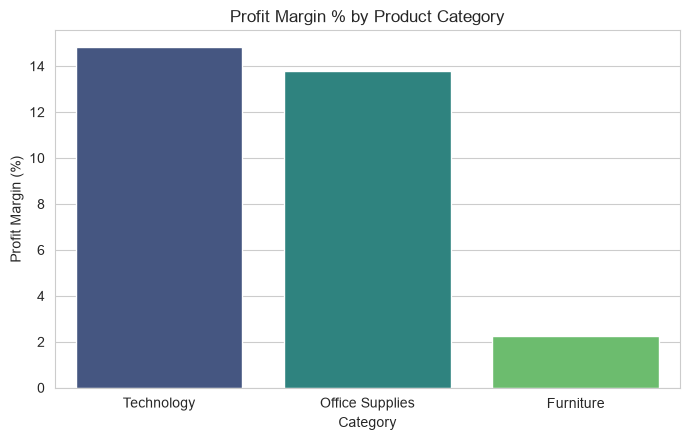

In [10]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=profit_by_category, x='Category', y='Profit_Margin_Pct', hue='Category', palette='viridis', legend=False)
plt.title('Profit Margin % by Product Category')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

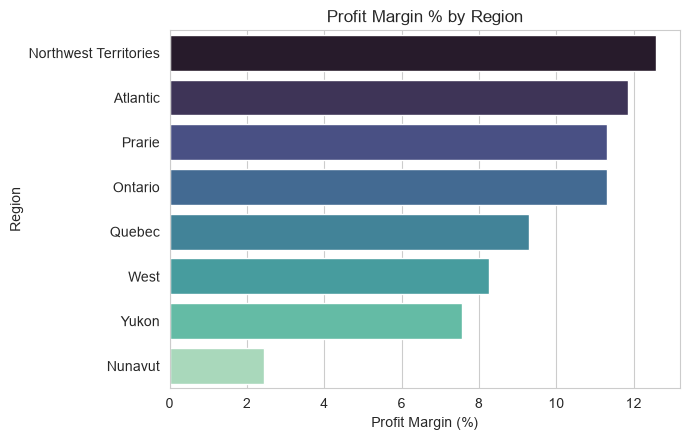

In [11]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=profit_by_region, x='Profit_Margin_Pct', y='Region', hue='Region', palette='mako', legend=False)
plt.title('Profit Margin % by Region')
plt.xlabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

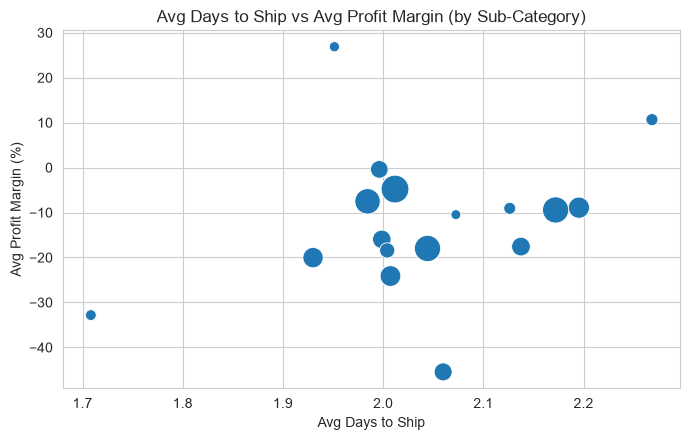

In [12]:
plt.figure(figsize=(7,4.5))
sns.scatterplot(data=turnover, x='Avg_Days_To_Ship', y='Avg_Profit_Margin', size='Total_Sales', legend=False, sizes=(50,400))
plt.title('Avg Days to Ship vs Avg Profit Margin (by Sub-Category)')
plt.xlabel('Avg Days to Ship')
plt.ylabel('Avg Profit Margin (%)')
plt.tight_layout()
plt.show()

## 7. Key Insights & Strategic Recommendations

1. **Technology (14.8%) and Office Supplies (13.8%)** are the most profitable categories, while **Furniture is barely profitable at 2.3%** — dragged down heavily by Tables and Bookcases, which post consistent losses.
2. **Tables (-$191K) and Bookcases (-$99K)** are the top loss-making sub-categories — likely over-discounted or overstocked. Same for Office Machines (-$204K).
3. **Nunavut and Yukon regions have the weakest profit margins** (2.4% and 7.6%), while Northwest Territories and Atlantic perform best (>11%).
4. **Fulfillment speed (Days to Ship) shows only a weak correlation (~0.29) with profit margin at the category level**, and almost none at the individual order level — meaning shipping speed alone isn't driving losses; pricing/discounting strategy is the bigger lever.
5. **Recommendation:** Re-evaluate discount policy on Furniture (especially Tables/Bookcases), audit Nunavut/Yukon regional pricing, and consider phasing out or repricing the worst-performing sub-categories.